# Supermarket Customer Analytics & Product Recommendation System

### Unsupervised Machine Learning Project

**Project flow:**  
Data Understanding → EDA → Customer Behavior → Feature Engineering → K-Means → PCA → ARI Validation → Category Preferences → Product Similarity → Recommendation → Time-Based Evaluation → V1/V2/Baseline Comparison → Conclusion

> This notebook is the cleaned GitHub version of the original Colab project. The original EDA plots and important outputs are retained below, while the code is organized into a single professional notebook.


## 1. Problem Statement

A supermarket generates a large number of transaction records, but raw transactions do not directly tell us:

- which types of customers exist,
- how customers behave,
- which product categories customers prefer,
- which products are related to one another, and
- what products can be recommended to a customer.

This project uses **unsupervised machine learning** to discover customer segments and builds an **item-based recommendation system** from purchase behavior.


## 2. Objectives

1. Understand the structure and quality of the transaction dataset.
2. Perform detailed exploratory data analysis.
3. Convert transaction-level data into customer-level behavioral features.
4. Segment customers using K-Means clustering.
5. Visualize customer segments using PCA.
6. Validate clusters using Adjusted Rand Index (ARI).
7. Analyze customer category preferences.
8. Build an item-based product similarity model using cosine similarity.
9. Generate personalized product recommendations.
10. Evaluate recommendations using Precision@K and Recall@K.
11. Compare the personalized recommender with a popularity baseline.


## 3. Dataset Overview

The dataset contains **527,226 transaction records and 20 columns**.

Important fields include:

- `customer_id`
- `true_segment`
- `age`
- `gender`
- `monthly_income`
- `household_size`
- `invoice_no`
- `visit_number`
- `purchase_date`
- `product_category`
- `product`
- `quantity`
- `original_unit_price`
- `discount_pct`
- `unit_price`
- `total_amount`
- `month`
- `day_of_week`
- `purchase_hour`
- `used_discount`

There are **5,000 customers, 68,034 invoices and 50 products**. The original analysis found **no missing values and no duplicate rows**.


## 4. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option("display.max_columns", None)


## 5. Load the Dataset

In [ ]:
# Upload the CSV to Google Colab/Jupyter first.
# Expected filename:
# smart_supermarket_customer_behavior.csv

df = pd.read_csv("smart_supermarket_customer_behavior.csv")

print("Rows, Columns:", df.shape)
display(df.head())
display(df.tail())


Rows, Columns: (527226, 20)


## 6. First Data Analysis

We check:

- shape,
- first and last records,
- data types,
- statistical summary,
- missing values,
- duplicate rows,
- column names,
- numerical and categorical variables.


In [ ]:
print("========== SHAPE ==========")
print("Rows, Columns:", df.shape)

print("\n========== DATA INFO ==========")
df.info()

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE ROWS ==========")
print("Duplicate rows:", df.duplicated().sum())

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("\nNumerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)
print("Number of numerical columns:", len(numerical_columns))
print("Number of categorical columns:", len(categorical_columns))


Rows, Columns: (527226, 20)
Missing values: 0 across all columns
Duplicate rows: 0
Number of numerical columns: 15
Number of categorical columns: 5


## 7. Categorical Data Analysis

The categorical variables show the composition of the customer and product data.

### Key outputs

- `true_segment`: 5 categories
- `gender`: 2 categories
- `product_category`: 10 categories
- `product`: 50 products
- `purchase_date`: 55,852 unique timestamps


In [ ]:
for col in categorical_columns:
    print(f"\n========== {col.upper()} ==========")
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts().head(15))


### Important category counts from the original analysis

| Category | Count |
|---|---:|
| Budget_Family | 126,610 |
| Snack_Lover | 115,974 |
| Premium_Family | 109,902 |
| Fitness_Health | 92,054 |
| Student | 82,686 |

For gender:

| Gender | Count |
|---|---:|
| Male | 279,503 |
| Female | 247,723 |


## 8. Numerical Data Analysis

In [ ]:
print("========== NUMERICAL SUMMARY ==========")
display(df[numerical_columns].describe().T)

print("\n========== SKEWNESS ==========")
display(df[numerical_columns].skew().sort_values(ascending=False))


Important skewness values from the original analysis:
total_amount      2.032980
monthly_income    1.392113
unit_price        1.092911
original_unit_price 1.042918


## 9. Purchase Period and Dataset Scale

In [ ]:
df["purchase_date"] = pd.to_datetime(df["purchase_date"])

print("Purchase period:")
print("From:", df["purchase_date"].min())
print("To  :", df["purchase_date"].max())

print("\nTotal transactions:", len(df))
print("Unique customers:", df["customer_id"].nunique())
print("Unique invoices:", df["invoice_no"].nunique())
print("Unique products:", df["product"].nunique())


Purchase period:
From: 2025-01-01 10:11:00
To  : 2025-12-27 21:55:00
Total transactions: 527226
Unique customers: 5000
Unique invoices: 68034
Unique products: 50


# 10. Exploratory Data Analysis

This is the main business-understanding stage.

We investigate:
- transaction amount distribution,
- category sales,
- top products,
- customer spending,
- visits vs spending,
- shopping hour,
- discount behavior,
- quantity purchased,
- correlations.


### 10.1 Distribution of Transaction Amount

The transaction amount is right-skewed: most transactions are relatively smaller, with a long tail of high-value transactions.

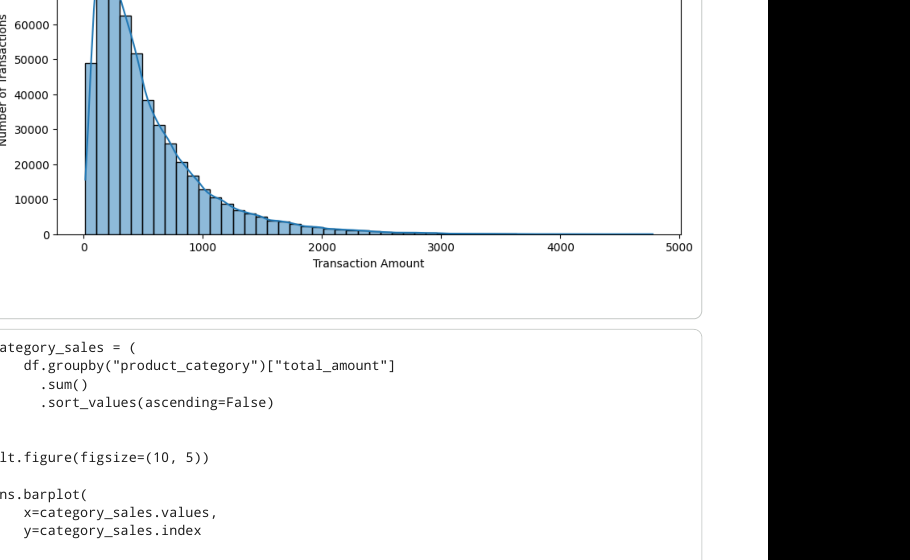

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.2 Total Sales by Product Category

Personal Care and Household are the strongest categories by total sales in the original analysis.

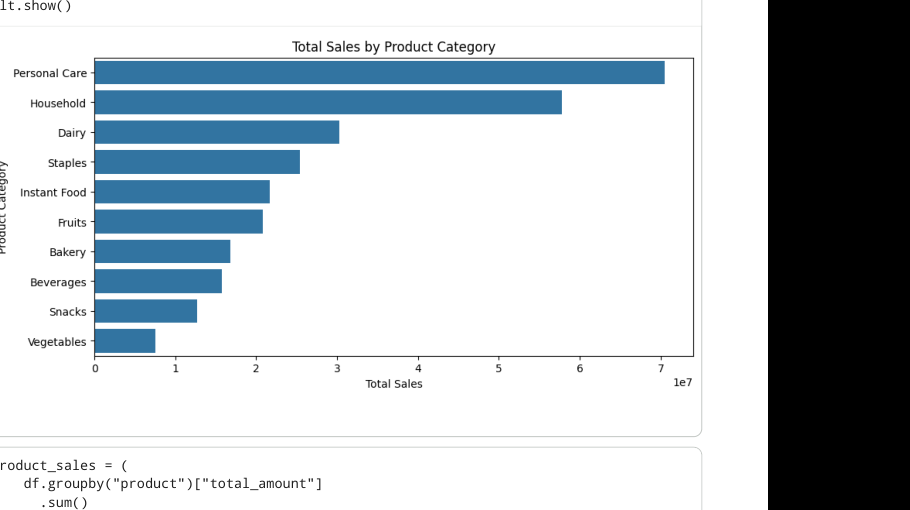

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.3 Top 15 Products by Total Sales

The top-selling products are concentrated in everyday personal-care and household products.

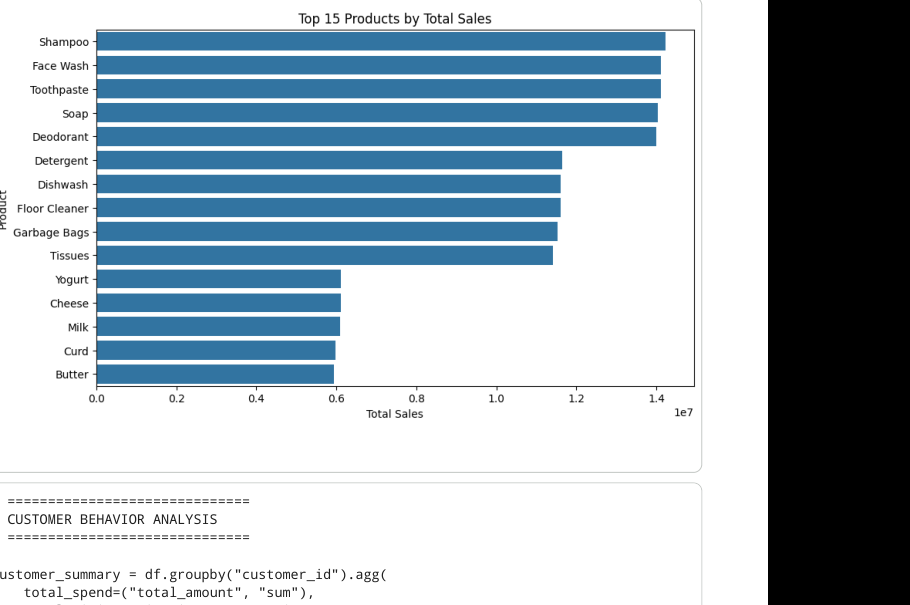

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.4 Distribution of Total Customer Spending

Customer-level spending is also right-skewed, with meaningful variation between customers.

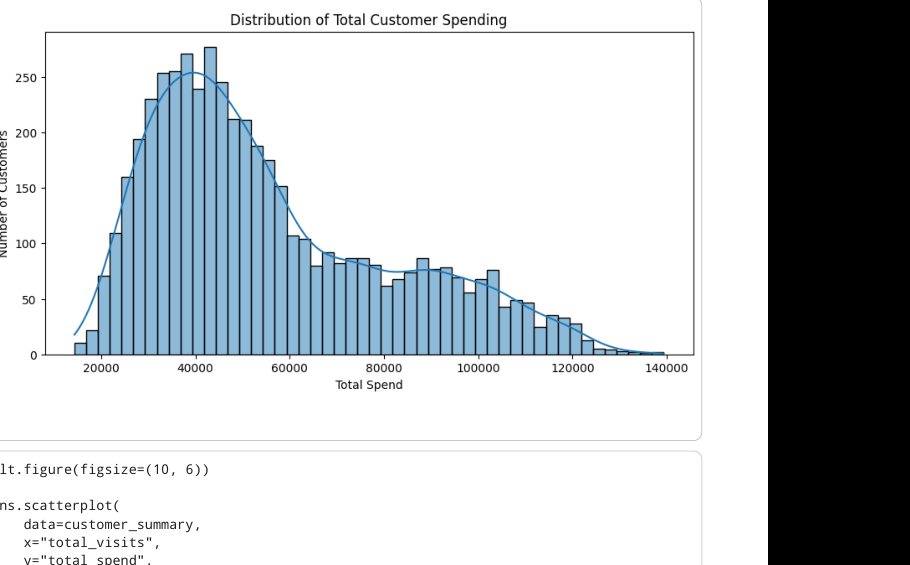

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.5 Customer Visits vs Total Spending

The scatter plot shows the relationship between visit frequency and total customer spending.

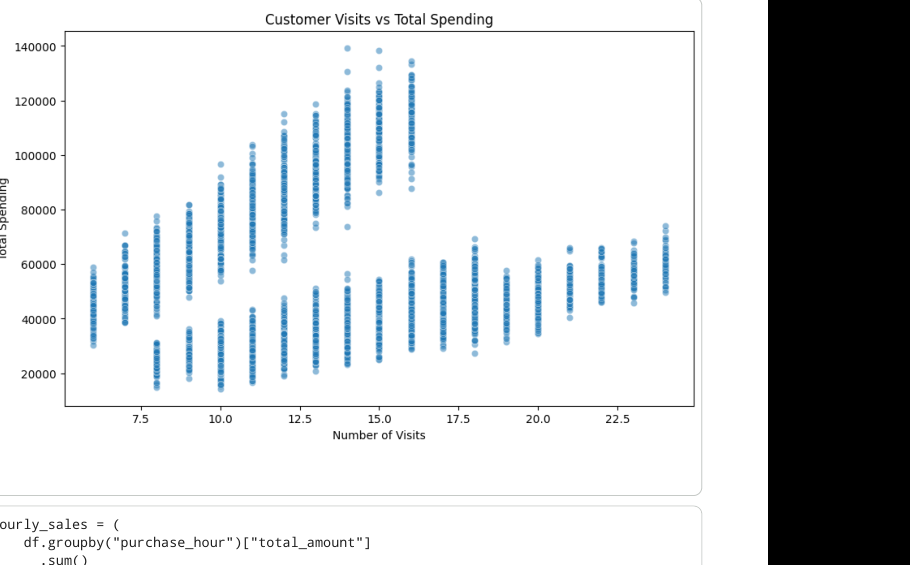

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.6 Sales by Shopping Hour

Sales increase through the afternoon and peak around the evening shopping hours.

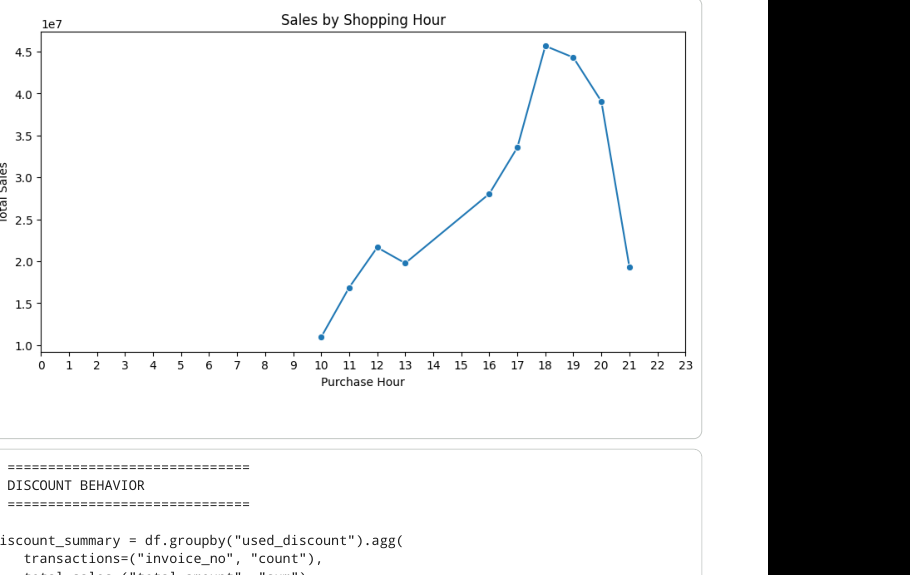

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.7 Transaction Amount by Discount Usage

The boxplot compares transaction-value distributions for customers who used and did not use discounts.

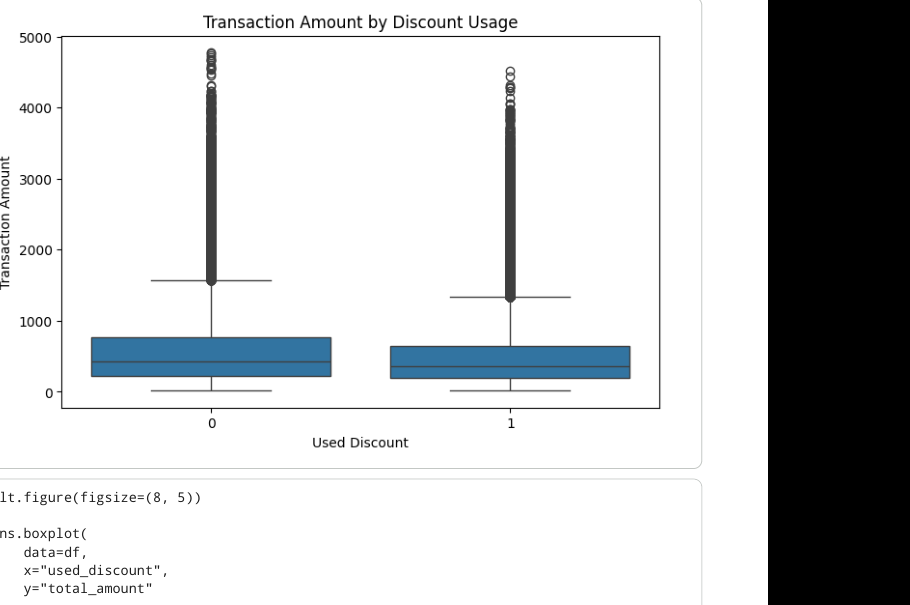

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.8 Total Quantity Purchased by Category

Personal Care has the highest total quantity purchased in the original data.

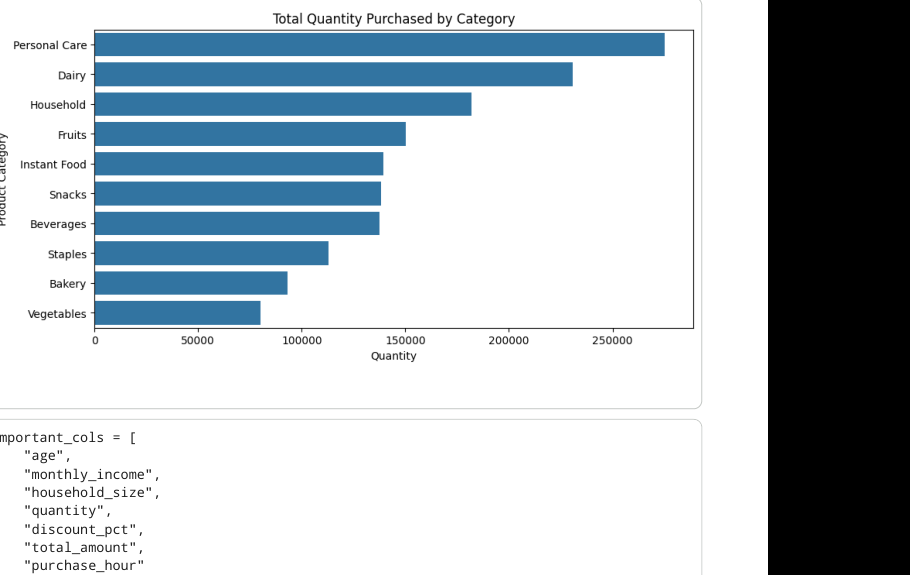

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

### 10.9 Correlation Between Numerical Features

Quantity has the strongest visible relationship with total amount among the selected variables (about 0.58).

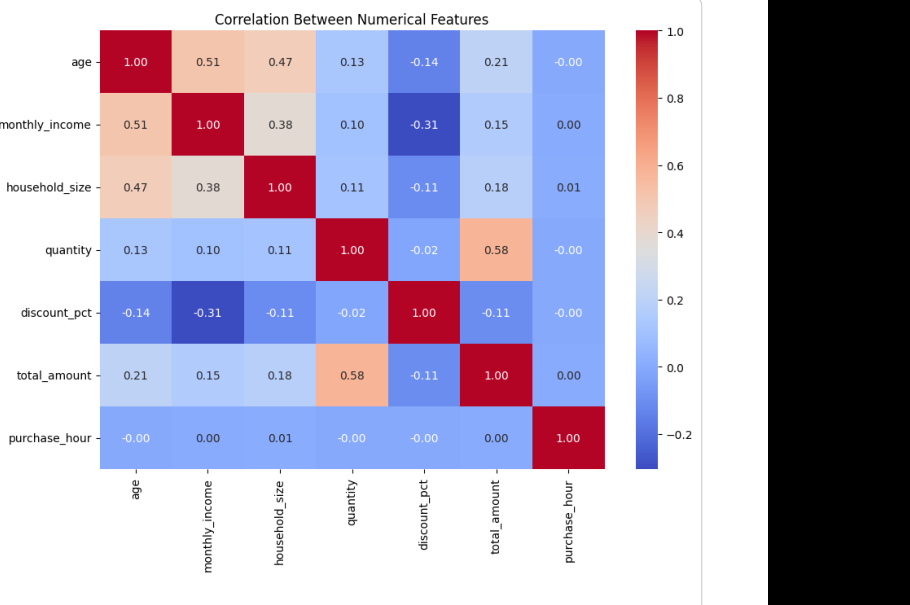

In [ ]:
# Reproduce this plot from the dataset using the corresponding EDA code below.
# The visible output below is retained from the supplied Colab export.

## 11. Customer-Level Behavior Analysis

In [ ]:
customer_summary = df.groupby("customer_id").agg(
    total_spend=("total_amount", "sum"),
    total_visits=("invoice_no", "nunique"),
    total_items=("quantity", "sum"),
    avg_transaction=("total_amount", "mean"),
    avg_discount=("discount_pct", "mean")
).reset_index()

print("Customer-level dataset shape:", customer_summary.shape)
display(customer_summary.describe().T)


Customer-level dataset shape: (5000, 6)
Mean total spend: 55843.93
Mean visits: 13.61
Mean items: 308.00
Mean transaction: 517.69


# 12. Customer-Level Feature Engineering

The transaction data is transformed into one row per customer.

### Features created

- age
- monthly income
- household size
- total spend
- total visits
- total items
- average transaction value
- average discount
- unique products
- unique categories
- average purchase hour
- spend per visit
- items per visit
- spend per item
- products per category
- spend-to-income ratio


In [ ]:
customer_features = df.groupby("customer_id").agg(
    age=("age", "first"),
    monthly_income=("monthly_income", "first"),
    household_size=("household_size", "first"),
    total_spend=("total_amount", "sum"),
    total_visits=("invoice_no", "nunique"),
    total_items=("quantity", "sum"),
    avg_transaction_value=("total_amount", "mean"),
    avg_discount=("discount_pct", "mean"),
    unique_products=("product", "nunique"),
    unique_categories=("product_category", "nunique"),
    avg_purchase_hour=("purchase_hour", "mean")
).reset_index()

customer_features["spend_per_visit"] = (
    customer_features["total_spend"] /
    customer_features["total_visits"]
)

customer_features["items_per_visit"] = (
    customer_features["total_items"] /
    customer_features["total_visits"]
)

customer_features["spend_per_item"] = (
    customer_features["total_spend"] /
    customer_features["total_items"]
)

customer_features["products_per_category"] = (
    customer_features["unique_products"] /
    customer_features["unique_categories"]
)

customer_features["spend_to_income_ratio"] = (
    customer_features["total_spend"] /
    (customer_features["monthly_income"] * 12)
)

print("Rows:", customer_features.shape[0])
print("Columns:", customer_features.shape[1])
print("Missing values:", customer_features.isnull().sum().sum())
print("Duplicate customers:", customer_features["customer_id"].duplicated().sum())

display(customer_features.head())


Rows: 5000
Columns: 17 (including customer_id)
Missing values: 0
Duplicate customers: 0


## 13. Select Features for Clustering and Scale Them

In [ ]:
clustering_features = [
    "age",
    "monthly_income",
    "household_size",
    "total_spend",
    "total_visits",
    "total_items",
    "avg_transaction_value",
    "avg_discount",
    "unique_products",
    "unique_categories",
    "avg_purchase_hour",
    "spend_per_visit",
    "items_per_visit",
    "spend_per_item",
    "products_per_category",
    "spend_to_income_ratio"
]

X = customer_features[clustering_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features used for clustering:", len(clustering_features))
print("X shape:", X.shape)
print("Scaled data shape:", X_scaled.shape)

scaled_df = pd.DataFrame(X_scaled, columns=clustering_features)
print("\nMean after scaling:")
print(scaled_df.mean().round(2))
print("\nStandard deviation after scaling:")
print(scaled_df.std().round(2))


Features used for clustering: 16
X shape: (5000, 16)
Scaled data shape: (5000, 16)
Mean after scaling: approximately 0
Standard deviation after scaling: 1


# 14. Choosing K for K-Means

Two approaches are used:

1. **Elbow Method** — observe how inertia decreases as K increases.
2. **Silhouette Score** — measure how well-separated the clusters are.


### Elbow Method

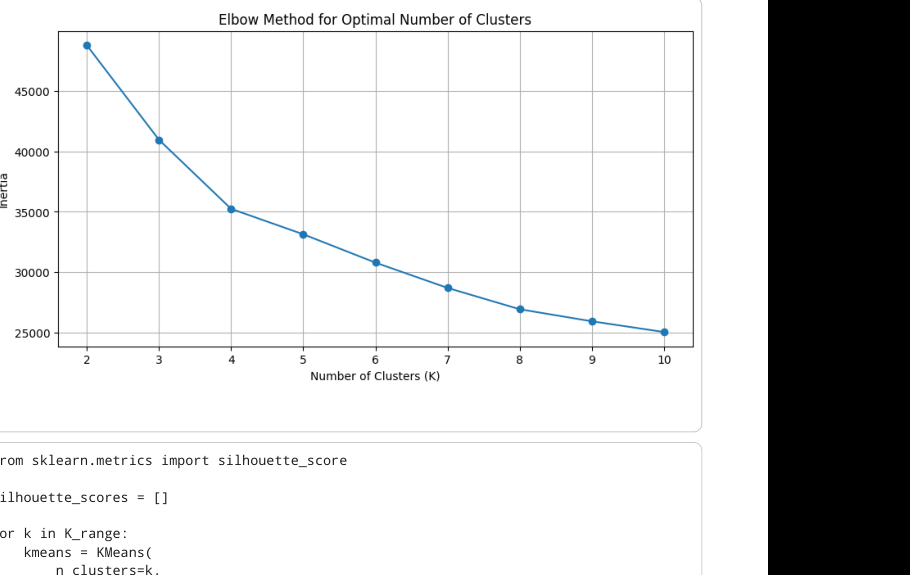

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(K_range)
plt.grid(True)
plt.show()


### Silhouette Score

| K | Silhouette Score |
|---:|---:|
| 2 | 0.367540 |
| 3 | 0.351568 |
| 4 | 0.239250 |
| 5 | 0.214900 |
| 6 | 0.211549 |
| 7 | 0.188300 |
| 8 | 0.188371 |
| 9 | 0.178586 |
| 10 | 0.178605 |

The original project selected **K = 3** for the final business segmentation.


# 15. Final K-Means Clustering

In [ ]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = final_kmeans.fit_predict(X_scaled)

print("Cluster distribution:")
display(customer_features["cluster"].value_counts().sort_index())

cluster_profile = customer_features.groupby("cluster").agg(
    customers=("customer_id", "count"),
    avg_age=("age", "mean"),
    avg_income=("monthly_income", "mean"),
    avg_spend=("total_spend", "mean"),
    avg_visits=("total_visits", "mean"),
    avg_items=("total_items", "mean"),
    avg_transaction=("avg_transaction_value", "mean"),
    avg_discount=("avg_discount", "mean"),
    avg_unique_products=("unique_products", "mean"),
    avg_categories=("unique_categories", "mean"),
    avg_spend_per_visit=("spend_per_visit", "mean"),
    avg_items_per_visit=("items_per_visit", "mean")
).round(2)

display(cluster_profile)


Cluster distribution:
Cluster 0: 1001
Cluster 1: 3004
Cluster 2: 995


### Cluster interpretation from the original analysis

- **Cluster 0:** older, high-spending customers with relatively high transaction values.
- **Cluster 1:** younger, larger group with more visits but lower average spending.
- **Cluster 2:** oldest/highest-income group, with high spending and fewer visits.

These are behavioral clusters, not labels assigned by the model.


# 16. PCA Visualization

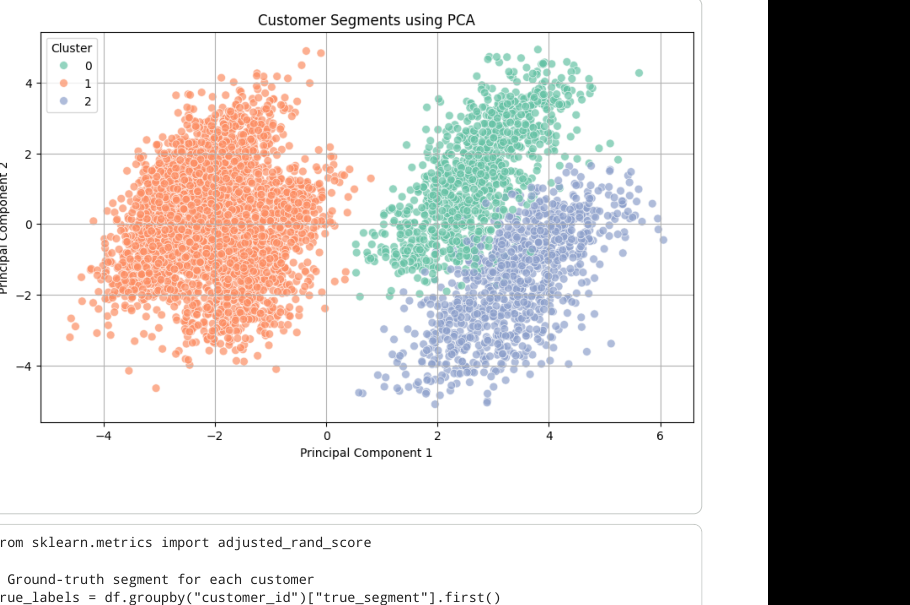

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": customer_features["cluster"]
})

print("Explained variance:")
print("PC1:", round(pca.explained_variance_ratio_[0] * 100, 2), "%")
print("PC2:", round(pca.explained_variance_ratio_[1] * 100, 2), "%")
print("Total:", round(pca.explained_variance_ratio_.sum() * 100, 2), "%")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=50,
    alpha=0.7
)
plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()


### PCA result

- PC1: **43.58%**
- PC2: **20.30%**
- Combined: **63.89%**

The two-dimensional PCA projection provides a visual view of the three customer clusters.


# 17. Validate Clusters with Adjusted Rand Index

The dataset already contains `true_segment`.

**Important:** `true_segment` is not used as a clustering feature. It is used only after clustering for external validation.


In [ ]:
true_labels = df.groupby("customer_id")["true_segment"].first()

validation_df = customer_features[["customer_id", "cluster"]].copy()
validation_df["true_segment"] = validation_df["customer_id"].map(true_labels)

ari_score = adjusted_rand_score(
    validation_df["true_segment"],
    validation_df["cluster"]
)

print("Adjusted Rand Index (ARI):", round(ari_score, 4))

cluster_vs_true = pd.crosstab(
    validation_df["cluster"],
    validation_df["true_segment"]
)

display(cluster_vs_true)


Adjusted Rand Index (ARI): 0.4778


### Interpretation

**ARI = 0.4778** indicates that the unsupervised clusters have meaningful agreement with the existing segment structure, but the three behavioral clusters do not reproduce all five original segment labels exactly.


# 18. Customer Category Preferences

A customer-category spending matrix is created to identify each customer's strongest product category.


In [ ]:
customer_category = pd.pivot_table(
    df,
    index="customer_id",
    columns="product_category",
    values="total_amount",
    aggfunc="sum",
    fill_value=0
)

customer_category_pct = customer_category.div(
    customer_category.sum(axis=1),
    axis=0
) * 100

category_columns = customer_category_pct.columns

customer_category_pct["dominant_category"] = (
    customer_category_pct[category_columns].idxmax(axis=1)
)

dominant_category_counts = (
    customer_category_pct["dominant_category"]
    .value_counts()
)

print("Most preferred category per customer:")
display(dominant_category_counts)


Personal Care    2262
Household        1398
Bakery            632
Instant Food      450
Staples           100
Fruits             61
Beverages          50
Dairy              39
Snacks               7
Vegetables           1


# 19. Customer-Product Matrix

For recommendation, every customer is represented by their total spending across the 50 products.

This creates a **5000 × 50** customer-product matrix.


In [ ]:
customer_product = pd.pivot_table(
    df,
    index="customer_id",
    columns="product",
    values="total_amount",
    aggfunc="sum",
    fill_value=0
)

print("Customer-Product Matrix Shape:", customer_product.shape)
display(customer_product.head())

product_similarity = cosine_similarity(customer_product.T)

product_similarity_df = pd.DataFrame(
    product_similarity,
    index=customer_product.columns,
    columns=customer_product.columns
)

print("Product Similarity Matrix Shape:", product_similarity_df.shape)
display(product_similarity_df.head())


Customer-Product Matrix Shape: (5000, 50)
Product Similarity Matrix Shape: (50, 50)


# 20. Item Similarity Example

Cosine similarity is used to find products with similar customer-purchase patterns.


In [ ]:
def get_similar_products(product_name, top_n=5):
    if product_name not in product_similarity_df.columns:
        print("Product not found.")
        return

    similar_products = (
        product_similarity_df[product_name]
        .drop(product_name)
        .sort_values(ascending=False)
        .head(top_n)
    )

    return pd.DataFrame({
        "Product": similar_products.index,
        "Similarity_Score": similar_products.values
    }).reset_index(drop=True)

display(get_similar_products("Apples", top_n=5))


Product  Similarity_Score
Grapes       0.751812
Mangoes      0.750347
Oranges      0.749036
Bananas      0.747217
Yogurt       0.623340


# 21. Personalized Product Recommendation — V1

V1 works as follows:

1. Take products already purchased by a customer.
2. Find products similar to those purchased products.
3. Remove products the customer already bought.
4. Add similarity scores across the customer's purchase history.
5. Return the top-N candidates.


In [ ]:
def recommend_products(customer_id, top_n=5):
    purchased_products = get_customer_products(customer_id).index.tolist()
    recommendation_scores = {}

    for product in purchased_products:
        similar_products = product_similarity_df[product].drop(product)

        for candidate, score in similar_products.items():
            if candidate not in purchased_products:
                recommendation_scores[candidate] = (
                    recommendation_scores.get(candidate, 0) + score
                )

    recommendations = (
        pd.Series(recommendation_scores)
        .sort_values(ascending=False)
        .head(top_n)
    )

    return pd.DataFrame({
        "Recommended_Product": recommendations.index,
        "Recommendation_Score": recommendations.values
    }).reset_index(drop=True)

def get_customer_products(customer_id):
    purchased = customer_product.loc[customer_id]
    return purchased[purchased > 0].sort_values(ascending=False)

display(recommend_products(10001, top_n=10))


Customer 10001 V1 recommendations:
Buns, Cake, Croissant, Bread, Yogurt, Milk, Butter, Detergent, Floor Cleaner, Tissues


# 22. Time-Based Train/Test Split

To evaluate recommendations realistically, the customer's **last visit is held out as test data**.

This prevents the model from seeing the future purchase history while generating recommendations.


In [ ]:
df_sorted = df.sort_values(
    ["customer_id", "purchase_date"]
).copy()

last_visit = df_sorted.groupby("customer_id")["invoice_no"].transform("max")

test_df = df_sorted[df_sorted["invoice_no"] == last_visit].copy()
train_df = df_sorted[df_sorted["invoice_no"] != last_visit].copy()

print("Training transactions:", train_df.shape)
print("Test transactions:", test_df.shape)
print("Customers in train:", train_df["customer_id"].nunique())
print("Customers in test:", test_df["customer_id"].nunique())


Training transactions: (486615, 20)
Test transactions: (40611, 20)
Customers in train: 5000
Customers in test: 5000


# 23. V1 Recommendation Evaluation

### Metrics

**Precision@K**

Among the top K recommendations, how many were actually purchased in the held-out visit?

**Recall@K**

Among all products actually purchased in the held-out visit, how many were recovered by the recommendation list?


In [ ]:
train_customer_product = pd.pivot_table(
    train_df,
    index="customer_id",
    columns="product",
    values="total_amount",
    aggfunc="sum",
    fill_value=0
)

train_product_similarity = cosine_similarity(train_customer_product.T)

train_product_similarity_df = pd.DataFrame(
    train_product_similarity,
    index=train_customer_product.columns,
    columns=train_customer_product.columns
)

def recommend_from_training(customer_id, top_n=10):
    purchased_products = (
        train_customer_product.loc[customer_id]
        .loc[lambda x: x > 0]
        .index.tolist()
    )

    recommendation_scores = {}

    for product in purchased_products:
        similar_products = train_product_similarity_df[product].drop(product)

        for candidate, score in similar_products.items():
            if candidate not in purchased_products:
                recommendation_scores[candidate] = (
                    recommendation_scores.get(candidate, 0) + score
                )

    return (
        pd.Series(recommendation_scores)
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )

def evaluate_recommendations(top_n=10):
    precisions = []
    recalls = []

    for customer_id in train_customer_product.index:
        actual_products = set(
            test_df[test_df["customer_id"] == customer_id]["product"]
        )
        recommended_products = set(
            recommend_from_training(customer_id, top_n=top_n)
        )

        if len(actual_products) == 0:
            continue

        hits = len(actual_products & recommended_products)
        precisions.append(hits / top_n)
        recalls.append(hits / len(actual_products))

    return np.mean(precisions), np.mean(recalls)

precision_5, recall_5 = evaluate_recommendations(5)
precision_10, recall_10 = evaluate_recommendations(10)

print("Precision@5 :", round(precision_5, 4))
print("Recall@5    :", round(recall_5, 4))
print("Precision@10:", round(precision_10, 4))
print("Recall@10   :", round(recall_10, 4))


Precision@5 : 0.0564
Recall@5    : 0.0412
Precision@10: 0.0459
Recall@10   : 0.0656


# 24. V2 — Spend-Weighted Similarity

V2 adds a customer-specific weight.

If a customer spends more on a product, that product contributes more strongly to the recommendation score.


In [ ]:
def recommend_v2(customer_id, top_n=10):
    customer_history = train_customer_product.loc[customer_id]
    customer_history = customer_history[customer_history > 0]

    recommendation_scores = {}
    total_spend = customer_history.sum()

    for product, spend in customer_history.items():
        weight = spend / total_spend

        similar_products = (
            train_product_similarity_df[product]
            .drop(product)
        )

        for candidate, similarity in similar_products.items():
            if candidate not in customer_history.index:
                score = weight * similarity
                recommendation_scores[candidate] = (
                    recommendation_scores.get(candidate, 0) + score
                )

    return (
        pd.Series(recommendation_scores)
        .sort_values(ascending=False)
        .head(top_n)
    )

def evaluate_v2(top_n=10):
    precisions = []
    recalls = []

    for customer_id in train_customer_product.index:
        actual_products = set(
            test_df[test_df["customer_id"] == customer_id]["product"]
        )
        recommended_products = set(
            recommend_v2(customer_id, top_n=top_n).index
        )

        if len(actual_products) == 0:
            continue

        hits = len(actual_products & recommended_products)
        precisions.append(hits / top_n)
        recalls.append(hits / len(actual_products))

    return np.mean(precisions), np.mean(recalls)

precision_5_v2, recall_5_v2 = evaluate_v2(5)
precision_10_v2, recall_10_v2 = evaluate_v2(10)

print("Precision@5 :", round(precision_5_v2, 4))
print("Recall@5    :", round(recall_5_v2, 4))
print("Precision@10:", round(precision_10_v2, 4))
print("Recall@10   :", round(recall_10_v2, 4))


Precision@5 : 0.0559
Recall@5    : 0.0405
Precision@10: 0.0461
Recall@10   : 0.0655


# 25. Popularity Baseline

Before calling the personalized model the final solution, we need a simple baseline.

The popularity model recommends the products with the highest total quantity purchased in the training data.


In [ ]:
product_popularity = (
    train_df.groupby("product")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("========== TOP 10 POPULAR PRODUCTS ==========")
display(product_popularity.head(10))

def popularity_recommendation(top_n=10):
    return product_popularity.head(top_n).index.tolist()

def evaluate_popularity(top_n=10):
    precisions = []
    recalls = []

    recommendations = set(popularity_recommendation(top_n))

    for customer_id in train_customer_product.index:
        actual_products = set(
            test_df[test_df["customer_id"] == customer_id]["product"]
        )

        if len(actual_products) == 0:
            continue

        hits = len(actual_products & recommendations)
        precisions.append(hits / top_n)
        recalls.append(hits / len(actual_products))

    return np.mean(precisions), np.mean(recalls)

precision_5_pop, recall_5_pop = evaluate_popularity(5)
precision_10_pop, recall_10_pop = evaluate_popularity(10)

print("Precision@5 :", round(precision_5_pop, 4))
print("Recall@5    :", round(recall_5_pop, 4))
print("Precision@10:", round(precision_10_pop, 4))
print("Recall@10   :", round(recall_10_pop, 4))


Top products by quantity: Shampoo, Toothpaste, Soap, Face Wash, Deodorant, Cheese, Yogurt, Milk, Curd, Butter
Precision@5 : 0.2515
Recall@5    : 0.1754
Precision@10: 0.2319
Recall@10   : 0.3126


# 26. Recommendation Model Comparison

| Approach | Precision@5 | Recall@5 | Precision@10 | Recall@10 |
|---|---:|---:|---:|---:|
| V1 — Item Similarity | 0.0564 | 0.0412 | 0.0459 | 0.0656 |
| V2 — Spend Weighted | 0.0559 | 0.0405 | 0.0461 | 0.0655 |
| **Popularity Baseline** | **0.2515** | **0.1754** | **0.2319** | **0.3126** |

### What this tells us

The personalized similarity models did **not** outperform the simple popularity baseline on this particular held-out-last-visit evaluation.

That is an important ML lesson:

> A more complicated model is not automatically a better model. The baseline must be measured first.


# 27. Final Business Interpretation

### Customer Segmentation

The K-Means model identifies three customer groups with substantially different:

- income,
- total spending,
- visit frequency,
- quantity purchased,
- average transaction value.

This can support differentiated marketing and promotion strategies.

### Product Recommendation

The item-similarity approach successfully learns relationships between products, for example the strong similarity between products such as Apples, Grapes, Mangoes, Oranges and Bananas.

However, recommendation quality is ultimately judged by held-out behavior, and the popularity baseline performs better here.

### Practical Next Step

A stronger production recommender could combine:

- customer-specific similarity,
- product popularity,
- customer cluster,
- category preference,
- recency,
- purchase frequency,
- promotions,
- inventory availability.


# 28. Conclusion

This project developed an end-to-end supermarket analytics pipeline from raw transactions to customer segmentation and product recommendation.

The dataset contained **527,226 transactions from 5,000 customers and 50 products**. After EDA and customer-level feature engineering, 16 behavioral features were standardized and used for K-Means clustering.

The final three-cluster solution produced interpretable customer groups. PCA explained **63.89%** of the standardized variance in two dimensions, and external validation against `true_segment` produced an **ARI of 0.4778**.

For recommendations, two item-similarity approaches were tested:

- **V1:** similarity aggregation
- **V2:** spend-weighted similarity

Both were evaluated using a realistic time-based holdout where each customer's last visit was treated as test data.

The strongest tested recommender was the **popularity baseline**, with:

- Precision@5 = **0.2515**
- Recall@5 = **0.1754**
- Precision@10 = **0.2319**
- Recall@10 = **0.3126**

The most important takeaway is that **evaluation decides the winner, not model complexity**.


# 29. Future Improvements

1. Build a hybrid recommender combining popularity and personalized similarity.
2. Add recency and purchase-frequency features.
3. Use customer clusters in recommendation scoring.
4. Incorporate category preferences.
5. Try collaborative filtering / matrix factorization.
6. Tune similarity-vs-popularity weights using validation data.
7. Evaluate MAP@K and NDCG@K.
8. Handle cold-start customers and products.
9. Add business constraints such as stock availability and promotions.

---

## End of Project

**Notebook structure:** Title → Explanation → Code → Output → Interpretation → Conclusion
